In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
function_path = './func/'
sys.path.append(function_path)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from visualizaion_func import *

In [ ]:
from crmprtd import setup_logging
import sqlalchemy as sa
from sqlalchemy.orm import Session
import sys
function_path = '../'
sys.path.append(function_path)

save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
log_file_path = save_path

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)

session

#### Find the stations under network 2, and have all the variables I want

In [ ]:
# sql_text = sa.text("""
# SELECT s.station_id, h.station_name
# FROM meta_history h
# JOIN meta_station s
#     ON h.station_id = s.station_id
# WHERE s.network_id = 2

# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'MINIMUM_AIR_TEMPERATURE'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'MAXIMUM_AIR_TEMPERATURE'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'min_air_temp_snc_last_reset'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'max_air_temp_snc_last_reset'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'air_temp'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'pcpn_amt_pst1hr'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'snwfl_amt_pst1hr'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'snw_dpth'
# )
# ;

# """)

# with engine.begin() as conn:
#     df = pd.read_sql(sql_text, conn)

# df

### Get variables' data

In [ ]:
# stations_2 = df['station_id'].iloc[4:6].tolist()
stations_1 = [2655]
sql_text = sa.text("""
SELECT s.station_id, o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 2
AND s.station_id IN :stations
AND v.net_var_name IN (
    'MINIMUM_AIR_TEMPERATURE',
    'MAXIMUM_AIR_TEMPERATURE',
    'min_air_temp_snc_last_reset',
    'max_air_temp_snc_last_reset',
    'air_temp',
    'pcpn_amt_pst1hr',
    'snwfl_amt_pst1hr',
    'snw_dpth'
)
ORDER BY s.station_id, o.obs_time
""")

with engine.begin() as conn:
    df_obs = pd.read_sql(sql_text, conn, params={
                         "stations": tuple(stations_1)})

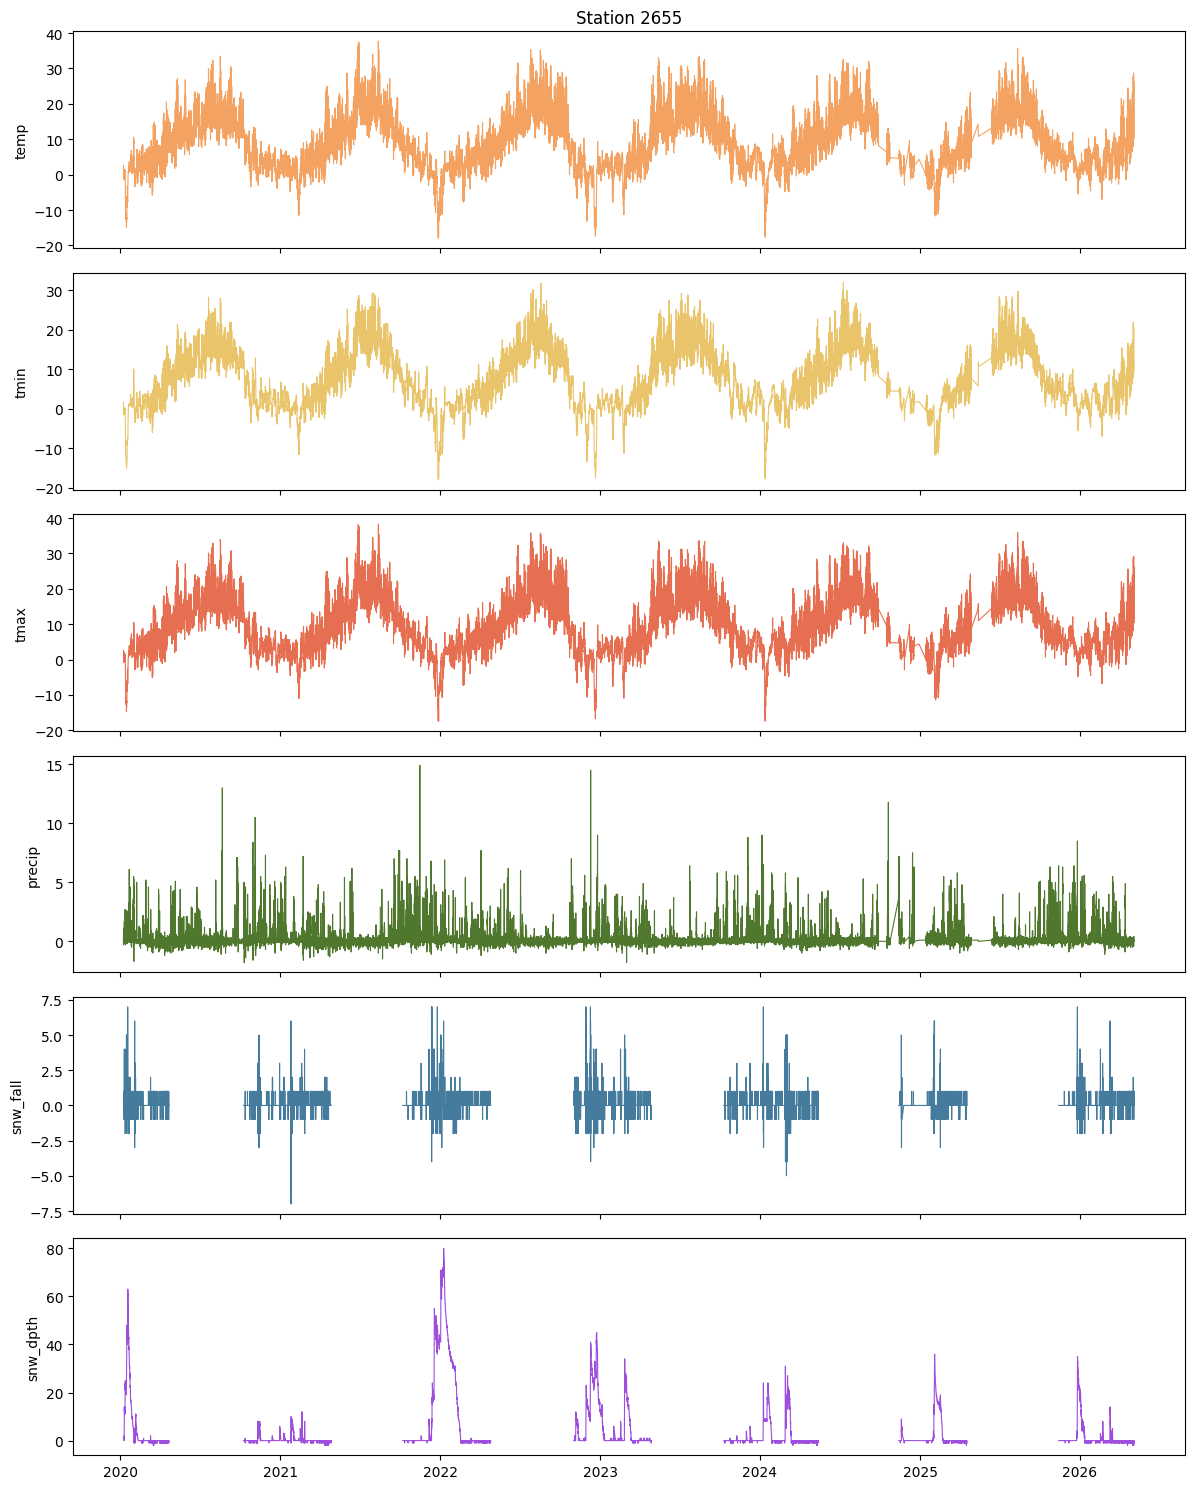

In [351]:
df_sql_list = []

for station_id, df_station in df_obs.groupby("station_id"):

    df_station = df_station.copy()
    df_station["obs_time"] = pd.to_datetime(df_station["obs_time"])

    df_sql = df_station.pivot_table(
        index="obs_time",
        columns="net_var_name",
        values="datum"
    ).sort_index()

    df_sql = df_sql.rename(columns={
        "min_air_temp_snc_last_reset": "tmin",
        "max_air_temp_snc_last_reset": "tmax",
        "air_temp": "temp",
        "pcpn_amt_pst1hr": "precip",
        "snwfl_amt_pst1hr": "snw_fall"
    })

    df_sql_list.append((station_id, df_sql))

stat_id = 0
station_df = df_sql_list[stat_id][1]

station_df = station_df[[
    'temp',
    'tmin',
    'tmax',
    'precip',
    'snw_fall',
    'snw_dpth'
]]

start_time = station_df.apply(lambda col: col.first_valid_index()).min()

station_df_trim = station_df.loc[start_time:]

color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
    "precip": "#4f772d",
}

plot_weather_data(station_df_trim, color_map=color_map,
                  title=f"Station {station_id}")

## 0.hourly_to_daily data

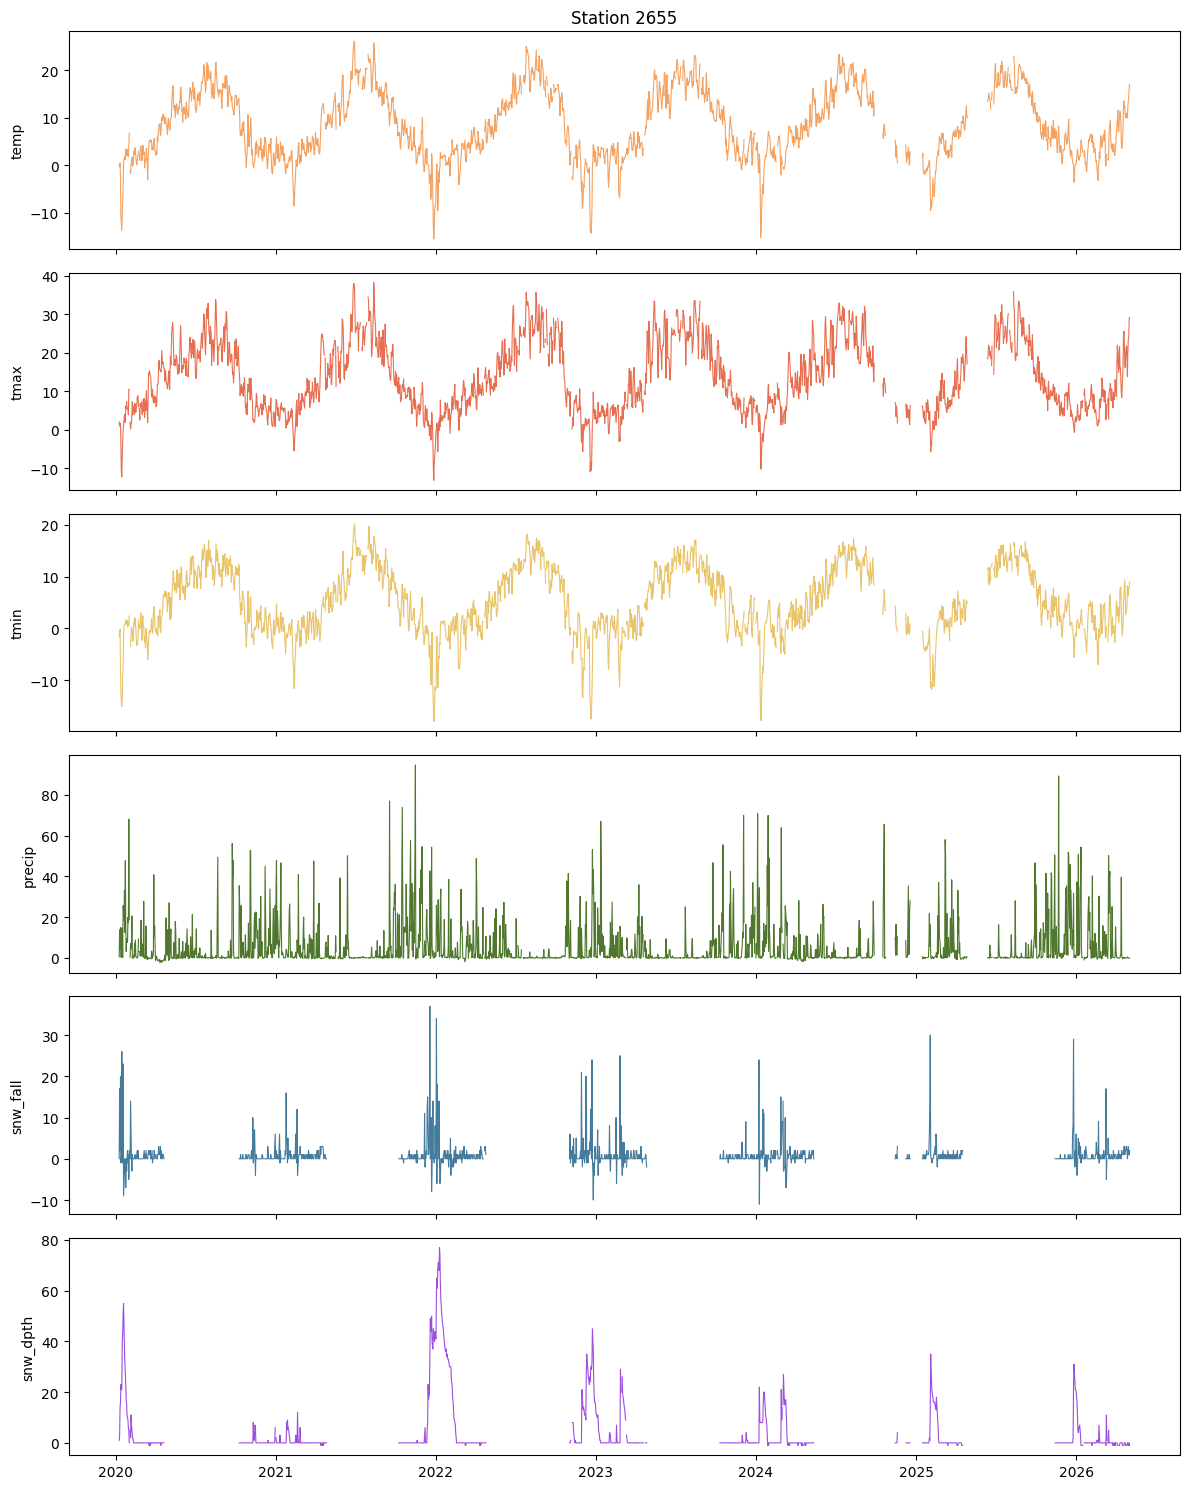

In [352]:
from func_0_hour_to_daily import *

daily_tas = hourly_to_daily(
    station_df_trim,
    cols=["tmax", "tmin", "temp"],
    agg_map={
        "temp": "mean",
        "tmax": "max",
        "tmin": "min",
    },
    min_hours=18
)


daily_sn = hourly_to_daily(
    station_df_trim,
    cols=["snw_fall", "snw_dpth"],
    agg_map={
        "snw_fall": "sum",
    },
    min_hours=18,
    snwd_hour=4
)


daily_precip = hourly_to_daily(
    station_df_trim,
    cols=["precip"],
    agg_map={"precip": "sum"},
    min_hours=18   # or 24 if strict
)

daily_all = pd.concat(
    [daily_tas, daily_precip, daily_sn],
    axis=1
)


daily_all

plot_weather_data(daily_all, color_map=color_map,
                  title=f"Station {station_id}")

## 1. Integrity check

### 1.0 Naught check

In [353]:
value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]

In [354]:
from func_int_1_naught_check import *

naught_result = qc_naught_and_trace(daily_all)

naught_result["temp_zero"].sum()
naught_result["precip_trace"].sum()

flag_precip_trace    0
dtype: int64

In [355]:
# combine all flag DataFrames into one
naught_all = pd.concat(naught_result.values(), axis=1)

# clean column names (optional)
naught_all.columns = naught_result.keys()

# now summarize
summary = naught_all.sum()

summary

temp_zero         0
tmin_zero         0
tmax_zero         0
precip_trace      0
snw_fall_trace    0
snw_dpth_trace    0
dtype: int64

#### Naught check plot

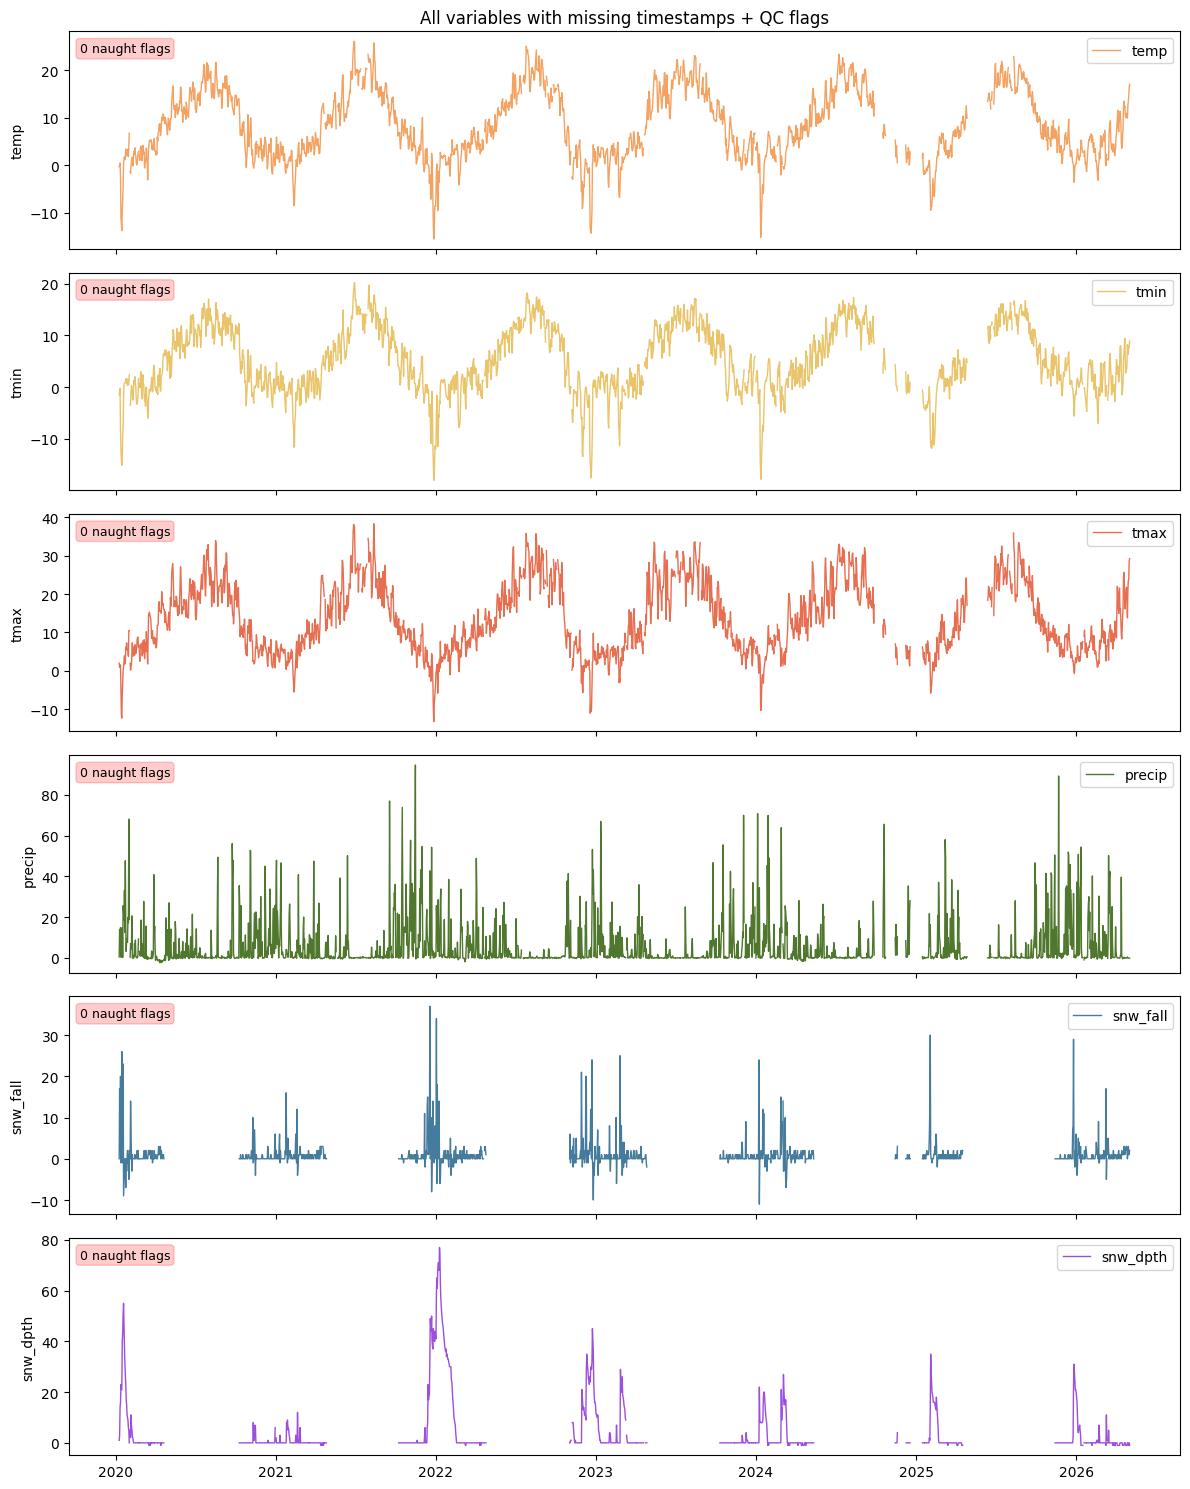

In [356]:
naught_map = {
    "temp": "temp_zero",
    "tmin": "tmin_zero",
    "tmax": "tmax_zero",
    "precip": "precip_trace",
    "snw_fall": "snw_fall_trace",
    "snw_dpth": "snw_dpth_trace",
}

plot_timeseries_with_naught_missing_multi(
    df=daily_all,
    miss_result_dict=None,
    color_map=color_map,
    naught_all=naught_all,
    naught_map=naught_map,
    value_cols=value_cols,
    title="All variables with missing timestamps + QC flags"
)

### 1.1 Pre missing value check

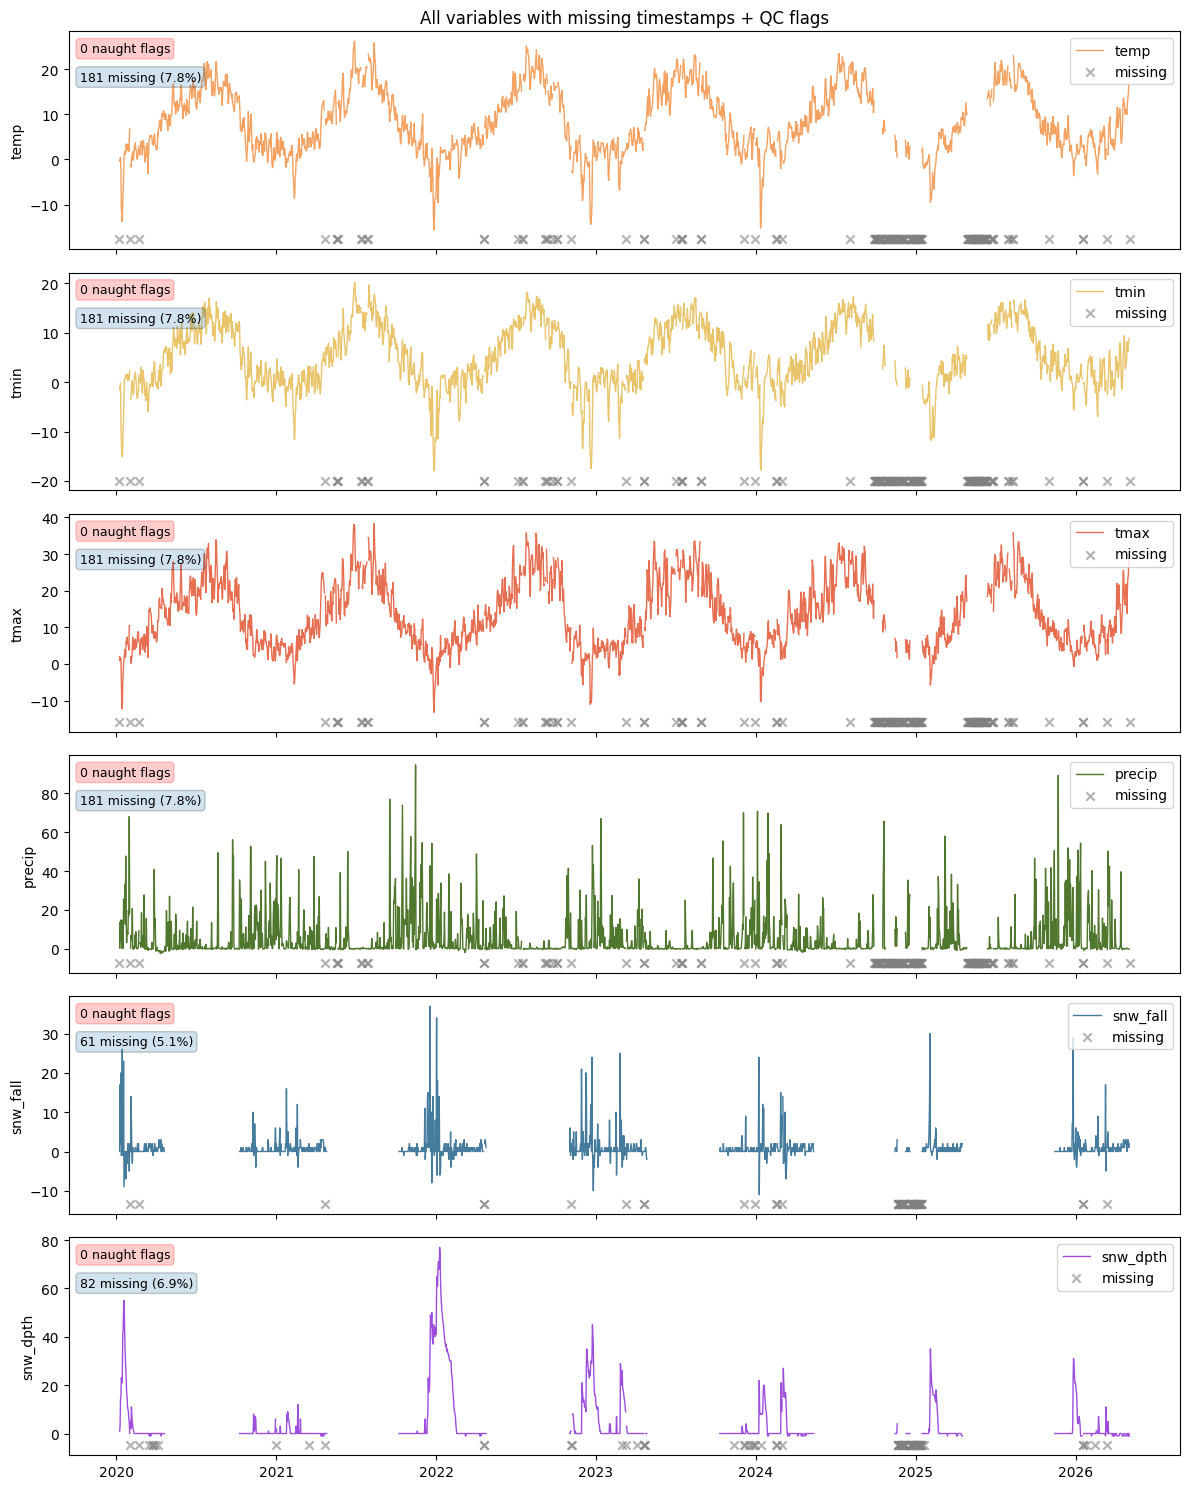

In [357]:
from func_int_5_missing_check import *

miss_result_dict = {}

for col in value_cols:
    miss_result_dict[col] = check_missing_timestamps(
        daily_all,
        value_col=col
    )

plot_timeseries_with_naught_missing_multi(
    df=daily_all,
    miss_result_dict=miss_result_dict,
    color_map=color_map,
    naught_all=naught_all,
    naught_map=naught_map,
    value_cols=value_cols,
    title="All variables with missing timestamps + QC flags"
)

### 1.2 Duplicate check

Check for
1. Duplicate entire years: “All values in one year = another year”
2. Duplicate months within the same year: “One month = another month”
3. Same calendar month across years: “Jan 2000 = Jan 2001”

4. Identical value–streak checks: •	If the same value repeats for many consecutive days, it’s unusual and probably an error.
	- Example thresholds given:
	- Temperature (TMAX/TMIN): 20 or more consecutive identical values
	- Snowfall (SNOW): 10 or more consecutive identical nonzero values
	- Snow depth (SNWD): 90 or more consecutive identical nonzero values

In [358]:
daily_all

net_var_name,temp,tmax,tmin,precip,snw_fall,snw_dpth
obs_time,,,,,,
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,-0.317391,2.0,-1.5,0.4,0.0,1.0
2020-01-10,-0.079167,0.9,-1.0,13.7,17.0,3.0
2020-01-11,0.441667,1.6,-0.2,4.2,2.0,14.0
2020-01-12,-2.504167,1.5,-8.1,14.8,20.0,16.0
...,...,...,...,...,...,...
2026-04-30,13.412500,23.5,6.3,-0.1,3.0,-1.0
2026-05-01,14.470833,23.9,7.8,-0.1,2.0,-1.0
2026-05-02,16.395833,28.6,7.8,-0.2,1.0,0.0


In [359]:
from func_int_2_dunplicate_check import *

value_cols = ["temp", "tmin", "tmax", "snw_fall", "snw_dpth", "precip"]


dup_result_dict = {}

for col in value_cols:

    dup_result_dict[col] = duplicate_check(
        daily_all,
        value_col=col,
    )

    print(f"\n🔍 Checking variable - {col}")

    print_duplicate_summary(dup_result_dict[col], value_col=col)

    # print(duplicate_summary_for_report(dup_result_dict[col], value_col=col))


🔍 Checking variable - temp

===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years: None

📆 Duplicate Months (within year): None

🌍 Duplicate Months (across years): None

---------------------------------
✅ Duplicate check PASSED — no issues found


🔍 Checking variable - tmin

===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years: None

📆 Duplicate Months (within year): None

🌍 Duplicate Months (across years): None

🌡️ TMAX–TMIN Flatline Months: None

---------------------------------
✅ Duplicate check PASSED — no issues found


🔍 Checking variable - tmax

===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years: None

📆 Duplicate Months (within year): None

🌍 Duplicate Months (across years): None

🌡️ TMAX–TMIN Flatline Months: None

---------------------------------
✅ Duplicate check PASSED — no issues found


🔍 Checking variable - snw_fall

===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years: None

📆 Duplicate Months (within year): None

🌍 Duplicate Months (across years): None

--

### 1.3 World record exceedance check

temp: below_min=0, above_max=0
tmin: below_min=0, above_max=0
tmax: below_min=0, above_max=0
precip: below_min=0, above_max=0
snw_fall: below_min=0, above_max=0
snw_dpth: below_min=0, above_max=0


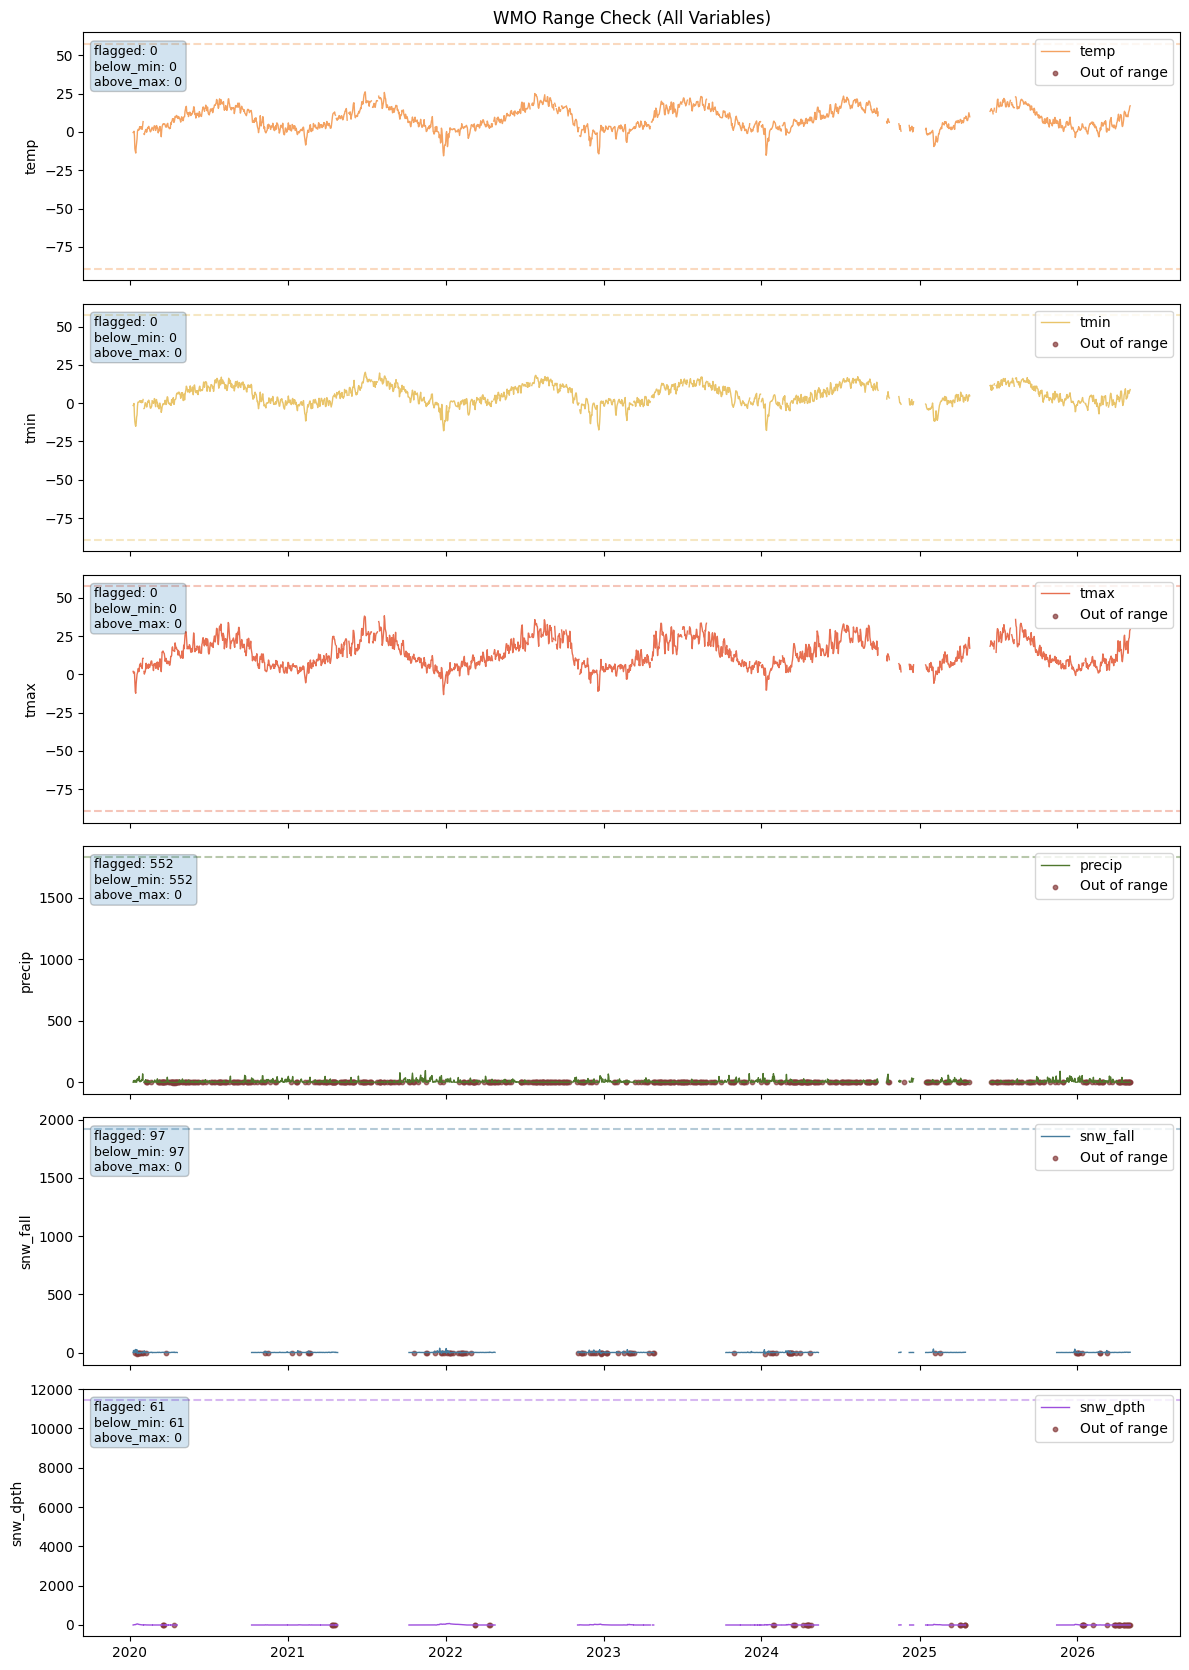

In [360]:
wmo_rules = {
    "temp":   {"min": -89.4, "max": 57.7},
    "tmin":   {"min": -89.4, "max": 57.7},
    "tmax":   {"min": -89.4, "max": 57.7},

    # ignore lower bound (handled separately)
    "precip":   {"min": None, "max": 1828.8},
    "snw_fall": {"min": None, "max": 1925},
    "snw_dpth": {"min": None, "max": 11460},
}

range_results = {}

for var, bounds in wmo_rules.items():

    if var not in daily_all.columns:
        continue  # skip if missing

    x = daily_all[var]

    if bounds["min"] is not None:
        n_below = (x < bounds["min"]).sum()
    else:
        n_below = 0

    if bounds["max"] is not None:
        n_above = (x > bounds["max"]).sum()
    else:
        n_above = 0

    print(f"{var}: below_min={n_below}, above_max={n_above}")

    res = qc_range_check(
        daily_all,
        value_col=var,
        min_val=bounds["min"],
        max_val=bounds["max"]
    )

    range_results[var] = res

    flag = res["flag"].to_frame(name=var)

range_flags = pd.concat(
    {var: res["flag"] for var, res in range_results.items()},
    axis=1
)

range_deviation = pd.concat(
    {var: res["deviation"] for var, res in range_results.items()},
    axis=1
)

plot_multi_range_check(
    df=daily_all,
    wmo_rules=wmo_rules,
    range_results=range_results,
    color_map=color_map,
    outrange_scatter_color='#843939'
)

### 1.4 Identical value–streak checks

In [361]:
from func_int_4_identical_value_streak_check import *


ind_result_dict = {}

for col in value_cols:

    ind_result_dict[col] = identify_value_streaks(
        daily_all,
        value_col=col,
    )

    print(f"\n🔍 Checking variable - {col}")

    # print_streak_summary(ind_result_dict[col])

    print(streak_summary_for_report(ind_result_dict[col]))


🔍 Checking variable - temp
{'variable': 'temp', 'threshold': 20, 'skip_zeros': False, 'n_streaks': 0, 'total_flagged_days': 0}

🔍 Checking variable - tmin
{'variable': 'tmin', 'threshold': 20, 'skip_zeros': False, 'n_streaks': 0, 'total_flagged_days': 0}

🔍 Checking variable - tmax
{'variable': 'tmax', 'threshold': 20, 'skip_zeros': False, 'n_streaks': 0, 'total_flagged_days': 0}

🔍 Checking variable - snw_fall
{'variable': 'snw_fall', 'threshold': 20, 'skip_zeros': False, 'n_streaks': 0, 'total_flagged_days': 0}

🔍 Checking variable - snw_dpth
{'variable': 'snw_dpth', 'threshold': 90, 'skip_zeros': True, 'n_streaks': 0, 'total_flagged_days': 0}

🔍 Checking variable - precip
{'variable': 'precip', 'threshold': 20, 'skip_zeros': False, 'n_streaks': 0, 'total_flagged_days': 0}


#### After this step, treat the bad values as missing values

In [362]:
daily_cleaned = daily_all.copy()

# 1. for the three variable, clip negatives to 0
zero_clip_vars = ["precip", "snw_fall", "snw_dpth"]
for var in zero_clip_vars:
    if var in daily_cleaned.columns:
        neg_mask = daily_cleaned[var] < 0
        daily_cleaned.loc[neg_mask, var] = 0

# 1. Remove out-of-range values from range checks
for var in range_flags.columns:
    mask = range_flags[var] == 1
    daily_cleaned.loc[mask, var] = np.nan

# 2. Remove naught / trace values from integrity checks
naught_var_map = {
    "temp": "temp_zero",
    "tmin": "tmin_zero",
    "tmax": "tmax_zero",
    "precip": "precip_trace",
    "snw_fall": "snw_fall_trace",
    "snw_dpth": "snw_dpth_trace",
}
for var, flag_col in naught_var_map.items():
    if var in daily_cleaned.columns and flag_col in naught_all.columns:
        daily_cleaned.loc[naught_all[flag_col] == True, var] = np.nan

# 3. Remove duplicate flatline temperature values
flatline_flags = None
for var in ["tmin", "tmax"]:
    if var in dup_result_dict:
        tmin_tmax_equal = dup_result_dict[var].get("tmin_tmax_equal")
        if tmin_tmax_equal is not None:
            flatline_flags = tmin_tmax_equal
            break

if flatline_flags is not None:
    for flag_col in ["flag_tmax_tmin_equal", "flag_month_flatline"]:
        if flag_col in flatline_flags.columns:
            mask = flatline_flags[flag_col] == True
            daily_cleaned.loc[mask, ["tmin", "tmax"]] = np.nan

# 4. Remove severe identical-value streaks from integrity checks
for var in value_cols:
    if var not in daily_cleaned.columns:
        continue
    streaks = ind_result_dict.get(var, {}).get("streaks", [])
    if not streaks:
        continue
    streak_mask = pd.Series(False, index=daily_cleaned.index)
    for start, end, _ in streaks:
        streak_mask |= (daily_cleaned.index >= pd.to_datetime(start)) & (
            daily_cleaned.index <= pd.to_datetime(end))
    daily_cleaned.loc[streak_mask, var] = np.nan

In [363]:
daily_cleaned

net_var_name,temp,tmax,tmin,precip,snw_fall,snw_dpth
obs_time,,,,,,
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,-0.317391,2.0,-1.5,0.4,0.0,1.0
2020-01-10,-0.079167,0.9,-1.0,13.7,17.0,3.0
2020-01-11,0.441667,1.6,-0.2,4.2,2.0,14.0
2020-01-12,-2.504167,1.5,-8.1,14.8,20.0,16.0
...,...,...,...,...,...,...
2026-04-30,13.412500,23.5,6.3,0.0,3.0,0.0
2026-05-01,14.470833,23.9,7.8,0.0,2.0,0.0
2026-05-02,16.395833,28.6,7.8,0.0,1.0,0.0


## 2. Outlier check

#### 2.1 Gap check

In [364]:
from func_clim_1_gap_check import *

gap_threshold = {
    "temp": 10,
    "tmin": 10,
    "tmax": 10,
    "precip": 300,
    "snw_dpth": 350,
}

gap_result_dict = {}

for col, thresh in gap_threshold.items():

    if col not in daily_cleaned.columns:
        continue

    print(f"\n🔍 Checking variable - {col}")

    if col in ["temp", "tmin", "tmax", "snw_dpth"]:
        res = gap_check_two_tailed(daily_cleaned, col, thresh)
    else:
        res = gap_check_one_tailed(daily_cleaned, col, thresh)

    gap_result_dict[col] = res

    n_flagged = res["flag"].sum()
    print(f"{col}: {n_flagged} flagged points")

gap_flags = pd.concat(
    {col: res["flag"] for col, res in gap_result_dict.items()},
    axis=1
)


🔍 Checking variable - temp
temp: 0 flagged points

🔍 Checking variable - tmin
tmin: 0 flagged points

🔍 Checking variable - tmax
tmax: 0 flagged points

🔍 Checking variable - precip
precip: 0 flagged points

🔍 Checking variable - snw_dpth
snw_dpth: 0 flagged points


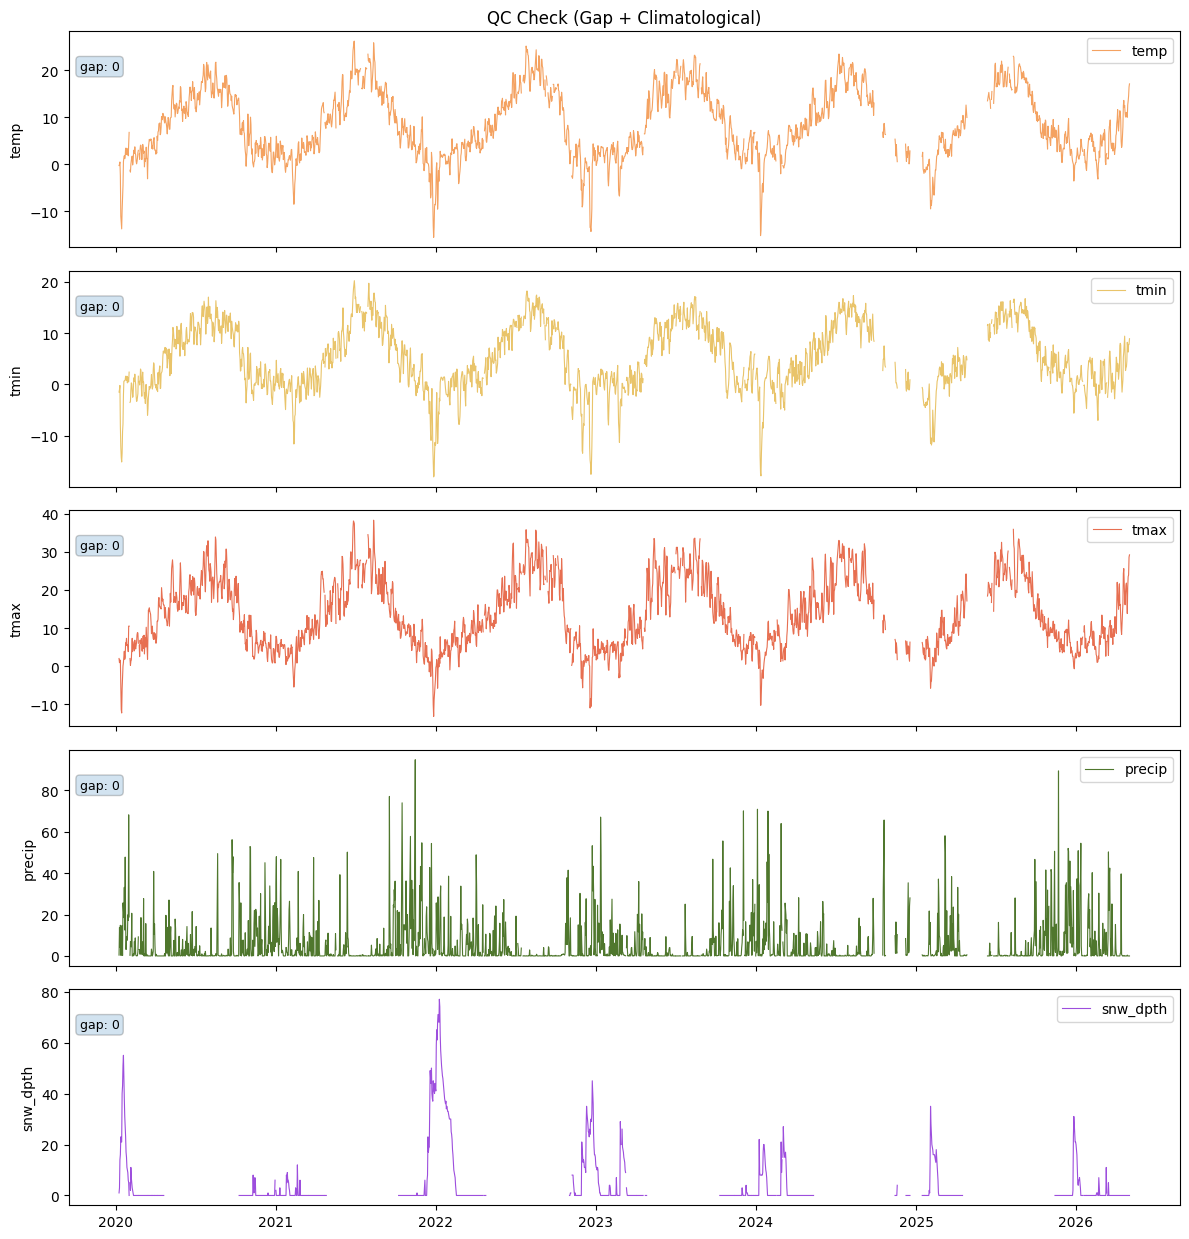

In [365]:
plot_clim_check_multi(
    df=daily_cleaned,
    color_map=color_map,
    gap_flags=gap_flags,
    clim_flags=None
)

#### 2.2 Climatological outlier checks

In [366]:
from func_clim_2_climatological_outlier_checks import *

clim_flags = {}

# temperature variables
for var in ["temp", "tmin", "tmax"]:
    if var in daily_cleaned.columns:
        clim_flags[var] = temp_outlier_flags(daily_cleaned, var, z_threshold=6)

# precipitation
if "precip" in daily_cleaned.columns:
    clim_flags["precip"] = precip_outlier_flags(daily_cleaned, per_threshold=9)

clim_flag_df = pd.concat(clim_flags.values(), axis=1)

clim_flag_df.sum()

temp      0
tmin      0
tmax      0
precip    0
dtype: int64

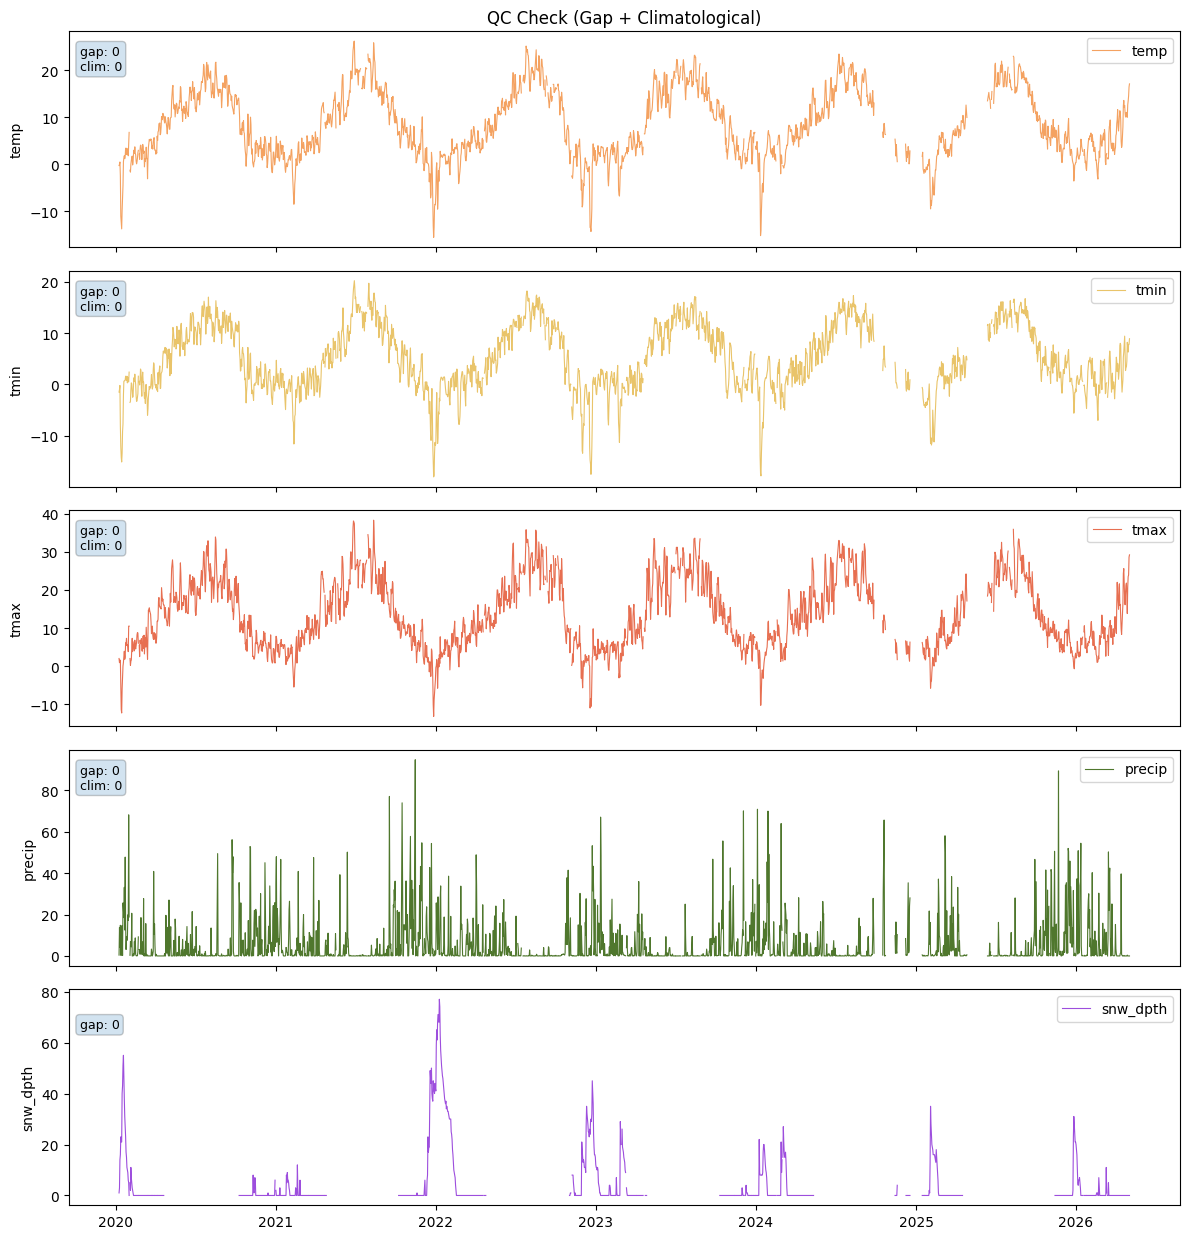

In [367]:
plot_clim_check_multi(
    df=daily_cleaned,
    color_map=color_map,
    gap_flags=gap_flags,
    clim_flags=clim_flag_df
)

## 3. Internal and temporal consistency checks

### 3.1 Temperature consistency check

- Basic physical consistency: TMAX >= TOBS >= TMIN;

- Spike / dip check: identifies temperatures that are at least 25C warmer or colder than the previous and following days.

- Lagged temperature range check: looks for differences in excess of 40C (i) between TMAX and the warmest TMIN reported on the previous, same, and following days and (ii) between TMIN and the coldest TMAX in the 3-day window centered on the day of the TMIN

In [388]:
from func_inttemp_1_tas_check import *
inttemp_tas_result = inttemp_temperature_consistency(daily_cleaned)
inttemp_tas_result['qc_label'] ==['bad']

obs_time
2020-01-08    missing
2020-01-09       good
2020-01-10       good
2020-01-11       good
2020-01-12       good
               ...   
2026-04-30       good
2026-05-01       good
2026-05-02       good
2026-05-03       good
2026-05-04    missing
Freq: D, Name: qc_label, Length: 2309, dtype: str

In [391]:
from func_QC_cleanning import *
daily_cleaned = apply_inttemp_tas_qc(daily_cleaned, inttemp_tas_result)

net_var_name,temp,tmax,tmin,precip,snw_fall,snw_dpth
obs_time,,,,,,
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,-0.317391,2.0,-1.5,0.4,0.0,1.0
2020-01-10,-0.079167,0.9,-1.0,13.7,17.0,3.0
2020-01-11,0.441667,1.6,-0.2,4.2,2.0,14.0
2020-01-12,-2.504167,1.5,-8.1,14.8,20.0,16.0
...,...,...,...,...,...,...
2026-04-30,13.412500,23.5,6.3,0.0,3.0,0.0
2026-05-01,14.470833,23.9,7.8,0.0,2.0,0.0
2026-05-02,16.395833,28.6,7.8,0.0,1.0,0.0


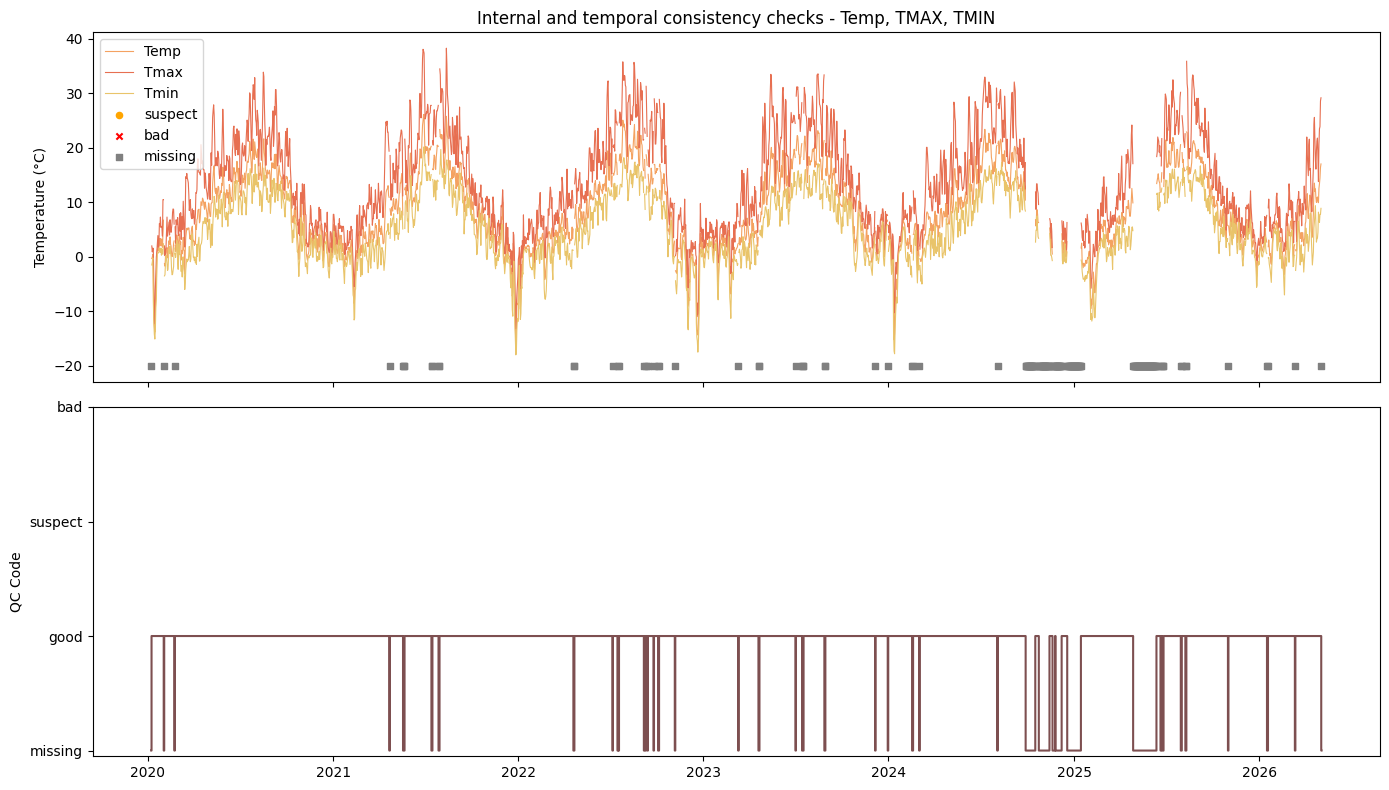

In [ ]:

plot_inttemp_tas_timeseries(
    daily_cleaned, inttemp_tas_result, color_map=color_map, missing_color="gray", state_color="#7d4f50")

### 3.2 Snow–temperature consistency check

In [370]:
from func_inttemp_2_snow_tmin_check import *

inttemp_snow_tmin_result = inttemp_snow_temp_consistency(daily_cleaned)
inttemp_snow_tmin_result

,flag_snow_warm,flag_snwd_warm,flag_snwd_warm_prev,flag_missing_snow,flag_missing_snwd,flag_missing_any
obs_time,,,,,,
2020-01-08,<NA>,<NA>,<NA>,1,1,1
2020-01-09,<NA>,<NA>,False,1,1,1
2020-01-10,False,False,False,0,0,0
2020-01-11,False,False,False,0,0,0
2020-01-12,False,False,False,0,0,0
...,...,...,...,...,...,...
2026-04-30,True,False,False,0,0,0
2026-05-01,False,False,False,0,0,0
2026-05-02,True,False,<NA>,0,0,0


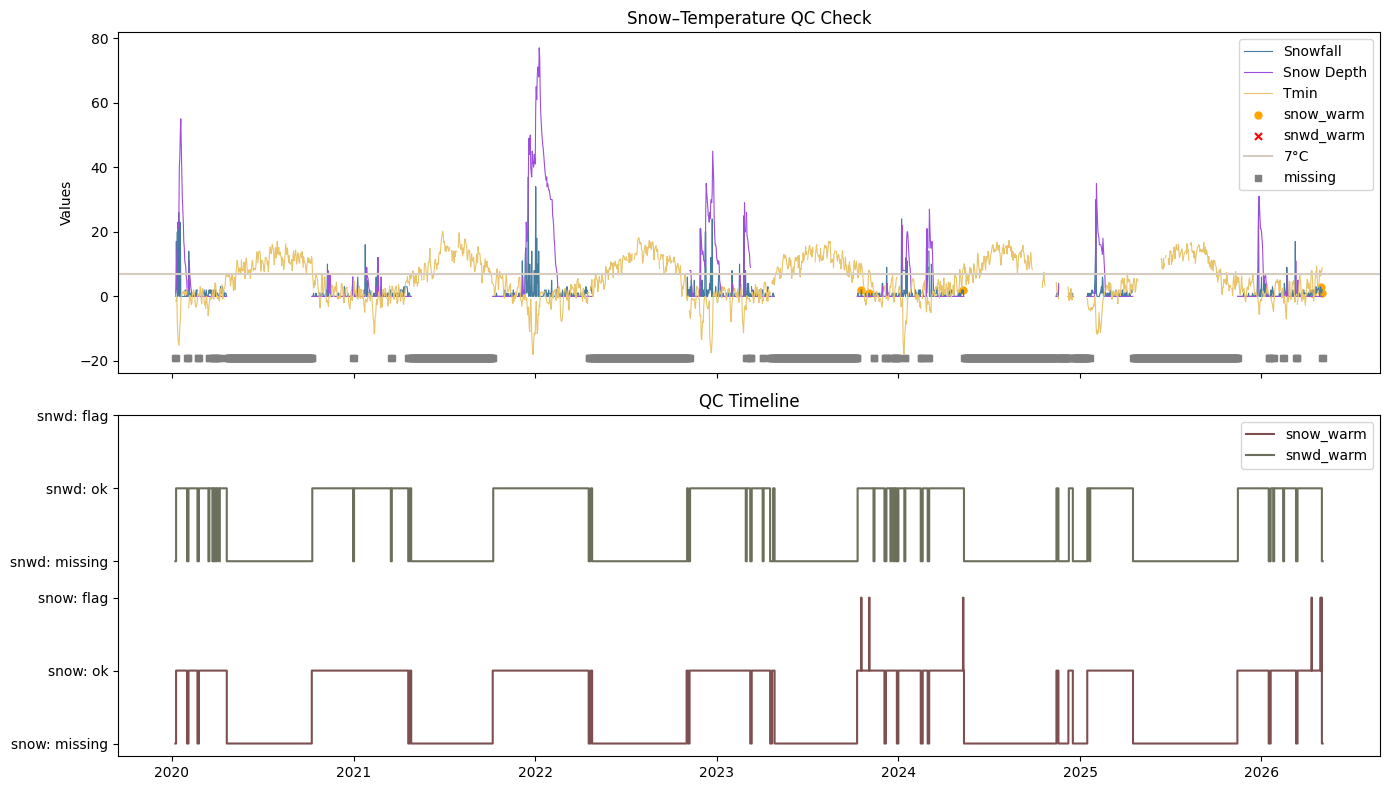

In [371]:
from visualizaion_func import *
plot_inttemp_snow_tmin_timeseries(
    daily_cleaned, inttemp_snow_tmin_result, color_map=color_map, missing_color="gray", state_color=["#7d4f50", "#6b705c"])

In [372]:
inttemp_snow_tmin_result

,flag_snow_warm,flag_snwd_warm,flag_snwd_warm_prev,flag_missing_snow,flag_missing_snwd,flag_missing_any
obs_time,,,,,,
2020-01-08,<NA>,<NA>,<NA>,1,1,1
2020-01-09,<NA>,<NA>,False,1,1,1
2020-01-10,False,False,False,0,0,0
2020-01-11,False,False,False,0,0,0
2020-01-12,False,False,False,0,0,0
...,...,...,...,...,...,...
2026-04-30,True,False,False,0,0,0
2026-05-01,False,False,False,0,0,0
2026-05-02,True,False,<NA>,0,0,0


### 3.3 Snowfall–snow depth consistency check

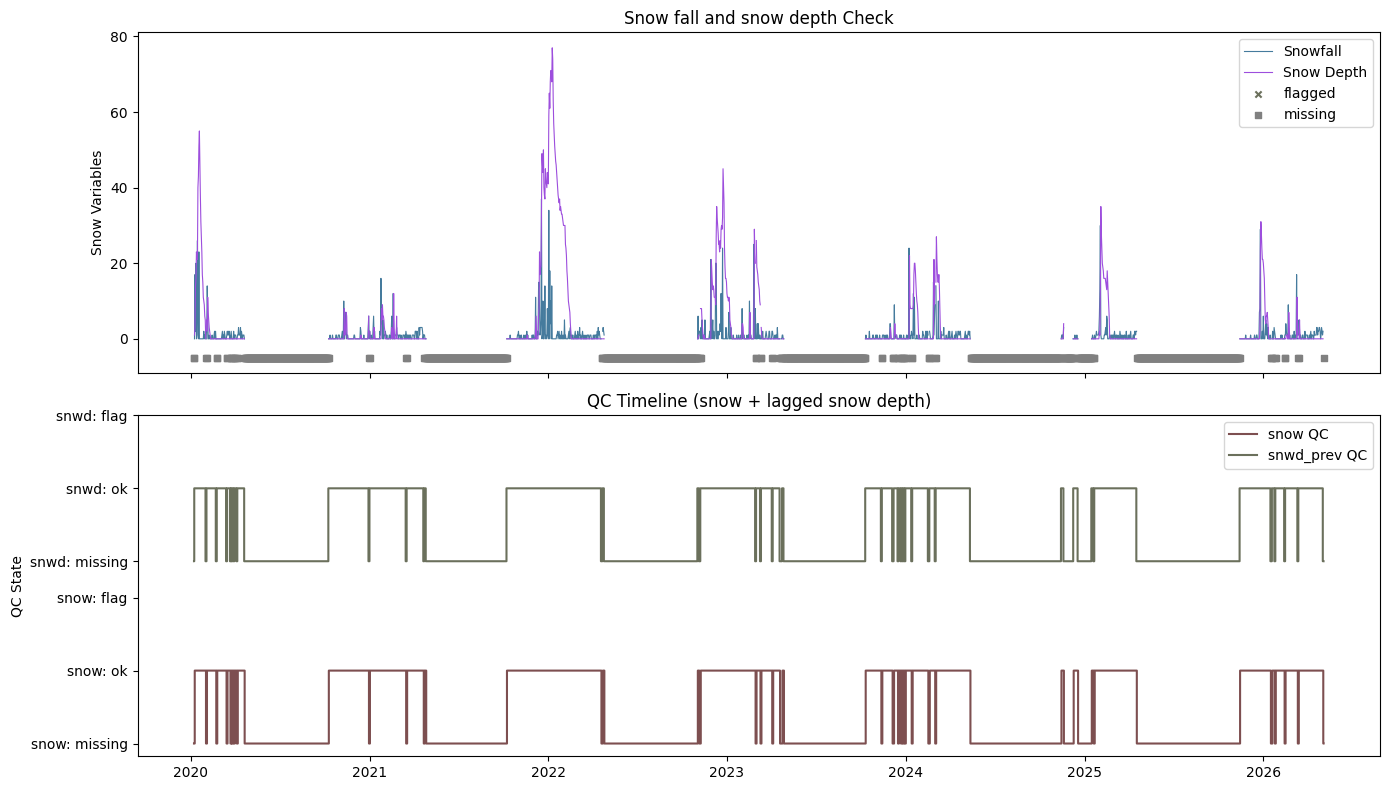

In [373]:
from func_inttemp_3_snow_fall_dpth_check import *
from visualizaion_func import *
inttemp_snow_fall_dpth_result = inttemp_snow_fall_dpth_consistency(
    daily_cleaned)

plot_inttemp_snow_fall_dpth_timeseries(
    daily_cleaned, inttemp_snow_fall_dpth_result, color_map=color_map, missing_color="gray", state_color=["#7d4f50", "#6b705c"], title="Snow fall and snow depth Check")

### 3.4 Snow_Precipitation consistency check

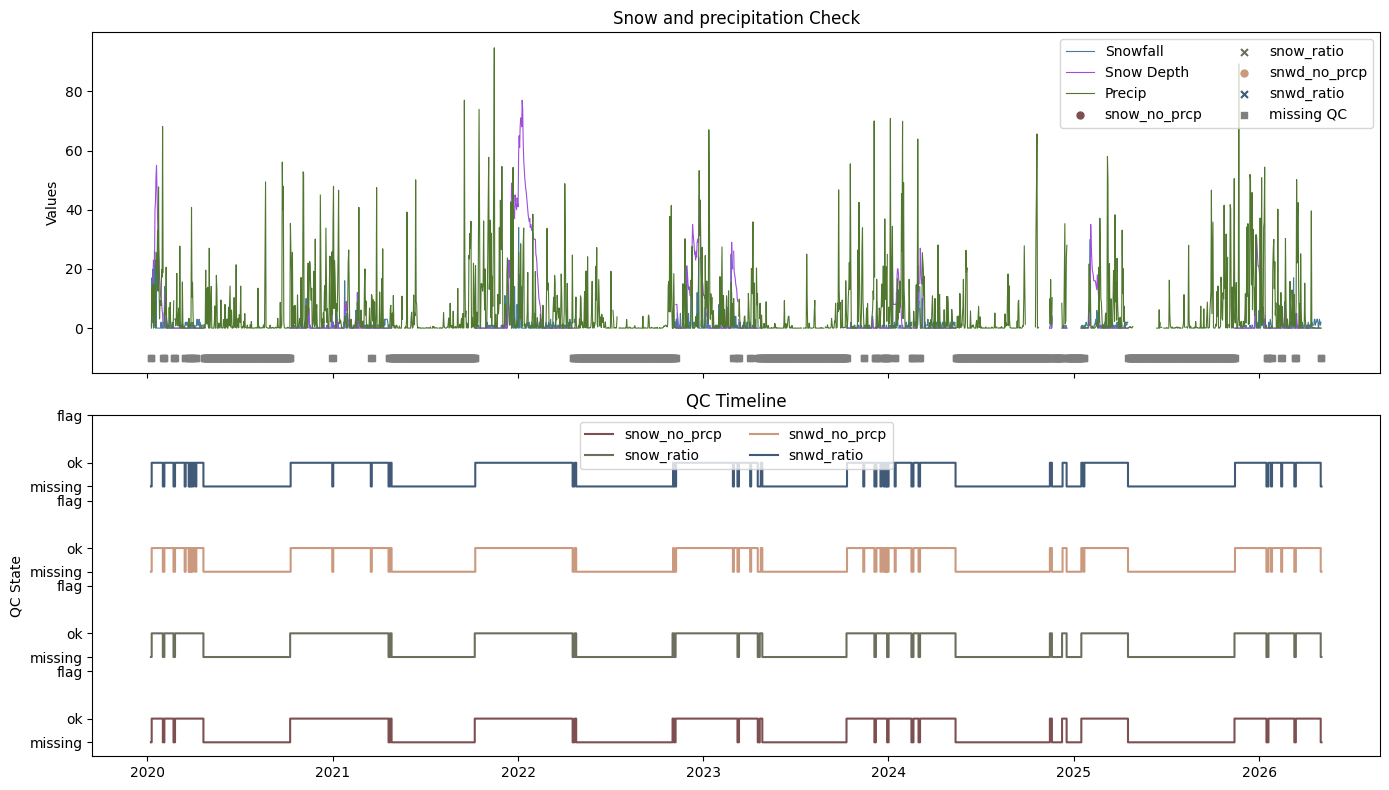

In [374]:
from func_inttempt_4_snow_precipitation_check import *
from visualizaion_func import *
inttemp_snow_precip_result = inttemp_snow_precip_consistency(
    daily_cleaned)

plot_inttemp_snow_precip_timeseries(
    daily_cleaned, inttemp_snow_precip_result, color_map=color_map, missing_color="gray", state_color=["#7d4f50", "#6b705c", "#cb997e", "#415a77"], title="Snow and precipitation Check")

## 4. Station-Level Quality Evaluation

#### 4.1 Missing value check

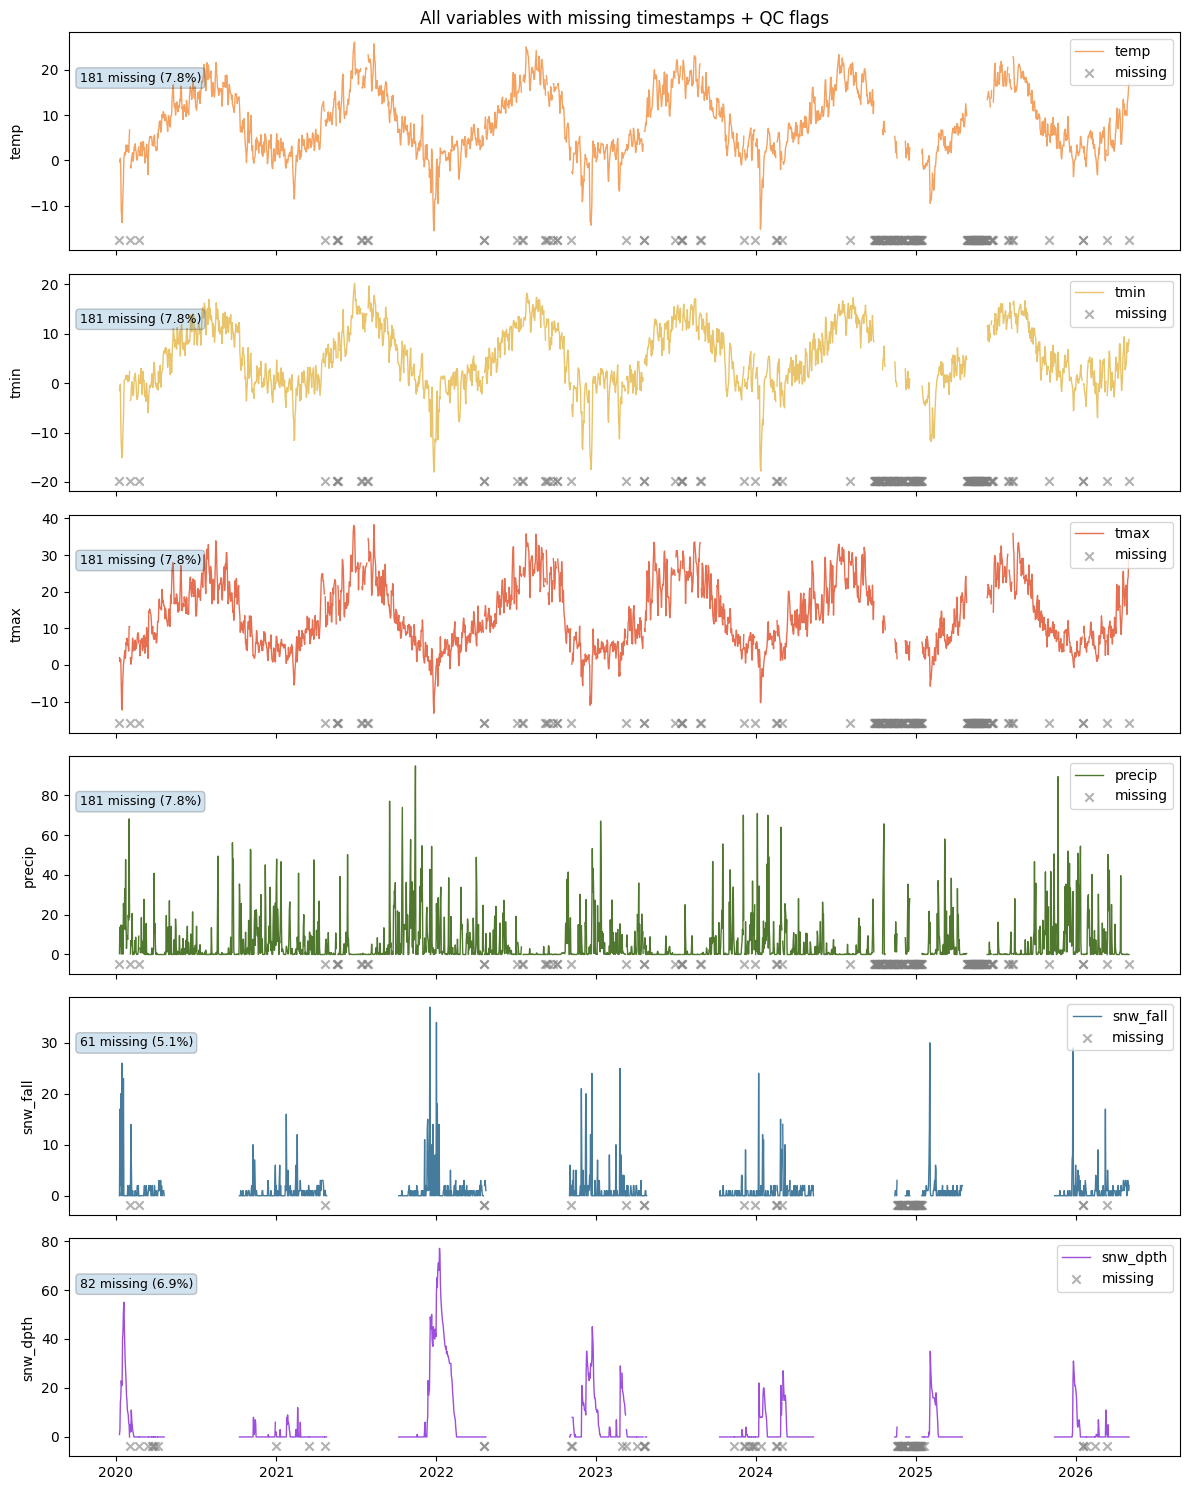

In [375]:
from func_int_5_missing_check import *
value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]
miss_result_dict = {}

for col in value_cols:
    miss_result_dict[col] = check_missing_timestamps(
        daily_cleaned,
        value_col=col
    )

plot_timeseries_with_naught_missing_multi(
    df=daily_cleaned,
    miss_result_dict=miss_result_dict,
    color_map=color_map,
    naught_all=None,
    naught_map=None,
    value_cols=value_cols,
    title="All variables with missing timestamps + QC flags"
)

### 4.2 Flag value check

In [380]:
import pandas as pd

# Import the station quality evaluation functions
from func_station_quality_evaluation import (
    summarize_flagged_values,
    analyze_temporal_coverage,
    evaluate_station_quality,
    get_station_rating
)

# Define variables
value_cols = ["temp", "tmin", "tmax", "snw_fall", "snw_dpth", "precip"]

# 4.2 Flag value check
# Summarize flagged values from all QC checks
summary_flags = summarize_flagged_values(
    daily_cleaned, value_cols, dup_result_dict, ind_result_dict,
    gap_flags, clim_flag_df, inttemp_tas_result,
    inttemp_snow_tmin_result, inttemp_snow_fall_dpth_result,
    inttemp_snow_precip_result
)

Total days in dataset: 2309

temp: 0 flagged days (0.00%)
  Sample dates: []

tmin: 0 flagged days (0.00%)
  Sample dates: []

tmax: 0 flagged days (0.00%)
  Sample dates: []

snw_fall: 6 flagged days (0.26%)
  snow_temp_warm: 6 days
  Sample dates: [Timestamp('2023-10-19 00:00:00'), Timestamp('2023-11-04 00:00:00'), Timestamp('2024-05-11 00:00:00'), Timestamp('2026-04-12 00:00:00'), Timestamp('2026-04-30 00:00:00')]

snw_dpth: 0 flagged days (0.00%)
  Sample dates: []

precip: 0 flagged days (0.00%)
  Sample dates: []



### 4.3 Temporal coverage analysis

In [381]:
# Analyze temporal coverage, continuity, and completeness
completeness_by_year = analyze_temporal_coverage(
    daily_cleaned, value_cols, miss_result_dict)

TEMPORAL COVERAGE ANALYSIS

Dataset period: 2020-01-08 to 2026-05-04
Total span: 2309 days (~6.32 years)

Years covered: 2020 to 2026 (7 years)

✅ Continuous years: All years from 2020 to 2026 are covered

Large gaps check (> 1 year = 365 days):
----------------------------------------------------------------------
temp: ✅ No large gaps (all gaps < 1 year)
tmin: ✅ No large gaps (all gaps < 1 year)
tmax: ✅ No large gaps (all gaps < 1 year)
snw_fall: ✅ No large gaps (all gaps < 1 year)
snw_dpth: ✅ No large gaps (all gaps < 1 year)
precip: ✅ No large gaps (all gaps < 1 year)

DATA COMPLETENESS BY YEAR AND VARIABLE

Year    temp        tmin        tmax        snw_fall    snw_dpth    precip      
--------------------------------------------------------------------------------
2020           0.8%         0.8%         0.8%       100.0%       100.0%         0.8%  
2021           2.2%         2.2%         2.2%       100.0%       100.0%         2.2%  
2022           3.3%         3.3%         3.3

### 4.4 Station Quality Evaluation Summary

**Variable-Level Rating Logic (with Large Gap Consideration):**

Each variable is assessed across three dimensions:

| Dimension | GOOD | CAUTION | UNRELIABLE | PROBLEMATIC | UNUSABLE |
|---|---|---|---|---|---|
| **Missing Rate** | < 20% | 20-30% | - | 30-60% | ≥ 60% |
| **Flag Rate** | < 20% | 20-30% | ≥ 30% | - | - |
| **Large Gaps** | None | Considered | Considered | Considered | - |

**Overall station rating rules:**

| Overall Rating | Rule | Recommendation |
|---|---|---|
| **❌❌ UNUSABLE STATION** | Any variable has `UNUSABLE` rating | REJECT - Station has unusable variables |
| **❌ POOR QUALITY** | ≥ 50% of variables are `PROBLEMATIC` | REJECT or USE WITH CAUTION |
| **⚠️⚠️ QUESTIONABLE QUALITY** | ≥ 50% of variables are `UNRELIABLE` + `PROBLEMATIC` combined | USE WITH CAUTION - Apply scrutiny to flagged data |
| **⚠️ MODERATE QUALITY** | Any variable is `UNRELIABLE` or `PROBLEMATIC` (but < 50%) | USABLE with caution - Monitor flagged data |
| **⚠️ FAIR QUALITY** | ≥ 2 variables have `CAUTION` rating | USABLE - Most variables acceptable |
| **✅ GOOD QUALITY** | All variables are `GOOD` (or none trigger above rules) | USABLE - Data quality acceptable |

**Assessment Flow:**
1. Check for UNUSABLE first (stops evaluation with rejection)
2. Check for PROBLEMATIC prevalence (≥50%)
3. Check for UNRELIABLE+PROBLEMATIC combined (≥50%)
4. Check for any UNRELIABLE/PROBLEMATIC presence
5. Check for multiple CAUTION variables (≥2)
6. Default to GOOD if none above apply

In [385]:
# Refined Station Quality Evaluation Flow
# This cell provides a clean, modular way to run the station quality evaluation

# Step 1: Import required functions
from func_station_quality_evaluation import (
    summarize_flagged_values,
    analyze_temporal_coverage,
    evaluate_station_quality,
    get_station_rating
)

# Step 2: Define variables to evaluate
value_cols = ["temp", "tmin", "tmax", "precip", "snw_fall", "snw_dpth"]

# Step 3: Summarize flagged values from all QC checks
summary_flags = summarize_flagged_values(
    daily_cleaned, value_cols, dup_result_dict, ind_result_dict,
    gap_flags, clim_flag_df, inttemp_tas_result,
    inttemp_snow_tmin_result, inttemp_snow_fall_dpth_result,
    inttemp_snow_precip_result
)

# Step 4: Analyze temporal coverage and completeness
completeness_by_year = analyze_temporal_coverage(
    daily_cleaned, value_cols, miss_result_dict)

# Step 5: Evaluate variable-level quality
variable_quality = evaluate_station_quality(
    daily_cleaned, value_cols, miss_result_dict, summary_flags)

# Step 6: Get overall station rating
variable_ratings = [q["rating"] for q in variable_quality.values()]
overall_rating, recommendation = get_station_rating(variable_ratings)

print("=" * 80)
print("OVERALL STATION QUALITY ASSESSMENT")
print("=" * 80)
print()
print(f"Overall Rating: {overall_rating}")
print()
print(f"Recommendation: {recommendation}")
print()

Total days in dataset: 2309

temp: 0 flagged days (0.00%)
  Sample dates: []

tmin: 0 flagged days (0.00%)
  Sample dates: []

tmax: 0 flagged days (0.00%)
  Sample dates: []

precip: 0 flagged days (0.00%)
  Sample dates: []

snw_fall: 6 flagged days (0.26%)
  snow_temp_warm: 6 days
  Sample dates: [Timestamp('2023-10-19 00:00:00'), Timestamp('2023-11-04 00:00:00'), Timestamp('2024-05-11 00:00:00'), Timestamp('2026-04-12 00:00:00'), Timestamp('2026-04-30 00:00:00')]

snw_dpth: 0 flagged days (0.00%)
  Sample dates: []

TEMPORAL COVERAGE ANALYSIS

Dataset period: 2020-01-08 to 2026-05-04
Total span: 2309 days (~6.32 years)

Years covered: 2020 to 2026 (7 years)

✅ Continuous years: All years from 2020 to 2026 are covered

Large gaps check (> 1 year = 365 days):
----------------------------------------------------------------------
temp: ✅ No large gaps (all gaps < 1 year)
tmin: ✅ No large gaps (all gaps < 1 year)
tmax: ✅ No large gaps (all gaps < 1 year)
precip: ✅ No large gaps (all ga

# Refined Station Quality Evaluation Flow

This notebook has been refactored to use modular functions for cleaner, more maintainable code. The quality evaluation process is now broken down into clear steps:

## Step-by-Step Quality Evaluation Process

1. **Flag Summarization**: Aggregate all QC flags from duplicate checks, identical streaks, gaps, climatological checks, and internal temporal consistency checks.

2. **Temporal Coverage Analysis**: Assess data completeness by year, check for large gaps (>1 year), and evaluate overall continuity.

3. **Variable-Level Quality Evaluation**: For each variable, evaluate missing rates, flag rates, and gap status to assign quality ratings (GOOD/CAUTION/UNRELIABLE/PROBLEMATIC/UNUSABLE).

4. **Overall Station Rating**: Combine variable ratings using priority-based logic to determine station usability.

## Benefits of Modular Design

- **Reusability**: Functions can be imported and used in other notebooks or scripts
- **Maintainability**: Changes to logic only need to be made in one place
- **Readability**: Clear function names and docstrings explain what each step does
- **Testing**: Individual functions can be unit tested independently
- **Debugging**: Easier to isolate issues in specific parts of the evaluation

The functions are stored in `func_station_quality_evaluation.py` and imported below.